In [1]:
# %%
import os
import tensorflow as tf

# 1. Suprime logs excessivos do TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 2. Configura a GPU e ativa o crescimento dinâmico de memória
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Ativa e Pronta: {gpus[0].name}")
    except RuntimeError as e:
        print(f"Erro na configuração da GPU: {e}")
else:
    print("⚠️ ATENÇÃO: Nenhuma GPU foi encontrada. O código rodará na CPU.")

# %%
from Functions.Graphs import *
from Functions.Utils import *
from scipy.signal import stft, hilbert
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import re

from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.utils import plot_model

fs = 25600

✅ GPU Ativa e Pronta: /physical_device:GPU:0


In [27]:


def load_bearing_data(path):
    """
    Carrega todas as tabelas STFT de uma pasta de rolamento e 
    retorna um array com formato (N_samples, 257, 129, 1).
    """
    samples = os.listdir(path)
    # Ordena os arquivos numericamente (ex: sample_1, sample_2...)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    
    data_list = []
    for sample in samples:
        sample_path = os.path.join(path, sample)
        df = pd.read_csv(sample_path)
        sig = df.iloc[:, :].values  # Formato: (257, 129)
        data_list.append(sig)
    
    # Converte para array -> (N_samples, 257, 129)
    bearing_array = np.array(data_list)
    
    # Adiciona a dimensão do canal no final -> (N_samples, 257, 129, 1)
    bearing_array = np.expand_dims(bearing_array, axis=-1)
    
    return bearing_array

# -------------------------------------------------------------
# 1. Defina os caminhos dos rolamentos que compõem o treino
# -------------------------------------------------------------
path_b1_1 = r'Dataset\XJTU\STFT\B1_1_env'
path_b2_2 = r'Dataset\XJTU\STFT\B2_2_env'
#path_b1_1 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B1_1'
#path_b2_2 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B2_2'

# 2. Carrega cada rolamento individualmente
data_b1_1 = load_bearing_data(path_b1_1) # Ex: (123, 257, 129, 1)
data_b2_2 = load_bearing_data(path_b2_2) # Ex: (161, 257, 129, 1)


# 3. Junta os dois conjuntos no eixo 0 (amostras)
X_train = np.concatenate([data_b1_1, data_b2_2], axis=0)

path_b1_2 = r'Dataset\XJTU\STFT\B1_2_env'
path_b2_5 = r'Dataset\XJTU\STFT\B2_5_env'
#path_b1_2 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B1_2'
#path_b2_5 = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\Raw\B2_5'


# 2. Carrega cada rolamento individualmente
data_b1_2 = load_bearing_data(path_b1_2) # Ex: (123, 257, 129, 1)
data_b2_5 = load_bearing_data(path_b2_5) # Ex: (161, 257, 129, 1)

# 3. Junta os dois conjuntos no eixo 0 (amostras)
X_test = np.concatenate([data_b1_2, data_b2_5], axis=0)

# ... (Seu código de carregamento e concatenação continua igual aqui)

# -------------------------------------------------------------
# NORMALIZAÇÃO MIN-MAX (Escala entre 0 e 1)
# -------------------------------------------------------------
# 1. Calcula o mínimo e o máximo Globais considerando APENAS o X_train
min_val = np.min(X_train)
max_val = np.max(X_train)

print(f"Valor Mínimo (Treino): {min_val:.4f}")
print(f"Valor Máximo (Treino): {max_val:.4f}")

# 2. Aplica a escala Min-Max em X_train usando os valores do próprio treino
X_train = (X_train - min_val) / (max_val - min_val)

# 3. Aplica a MESMA escala em X_test (usando min_val e max_val do TREINO)
X_test = (X_test - min_val) / (max_val - min_val)

# -------------------------------------------------------------
# VERIFICAÇÃO DOS LIMITES
# -------------------------------------------------------------
print(f"X_train -> Mín: {X_train.min():.2f}, Máx: {X_train.max():.2f}")
print(f"X_test  -> Mín: {X_test.min():.2f}, Máx: {X_test.max():.2f}")

print("Formato final de X_train:", X_train.shape)

Valor Mínimo (Treino): 0.0000
Valor Máximo (Treino): 11.8731
X_train -> Mín: 0.00, Máx: 1.00
X_test  -> Mín: 0.00, Máx: 1.26
Formato final de X_train: (284, 257, 130, 1)


In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_stft_autoencoder(input_shape=(257, 129, 1), latent_dim=32):
    """
    Constrói um Autoencoder Convolucional 2D para matrizes STFT.
    
    Parâmetros:
    -----------
    input_shape : tuple
        Formato do sinal de entrada (Frequência, Tempo, Canais). Ex: (257, 129, 1)
    latent_dim : int
        Número de características latentes a serem extraídas pelo Encoder.
    """
    
    visible = layers.Input(shape=input_shape, name="STFT_Input")

    # -------------------------------------------------------------------
    # 1. ENCODER
    # -------------------------------------------------------------------
    # Bloco 1: Redução espacial (Downsampling)
    e = layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(visible)
    e = layers.BatchNormalization()(e)
    e = layers.LeakyReLU()(e)

    # Bloco 2: Redução espacial
    e = layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(e)
    e = layers.BatchNormalization()(e)
    e = layers.LeakyReLU()(e)

    # Bloco 3: Ajusta a profundidade diretamente para o tamanho `latent_dim`
    e = layers.Conv2D(filters=latent_dim, kernel_size=(3, 3), strides=(1, 1), padding="same")(e)
    e = layers.BatchNormalization()(e)
    encoder_last_conv = layers.LeakyReLU()(e)

    # --- CAPTURA DINÂMICA DAS DIMENSÕES DO ENCODER ---
    enc_h, enc_w, enc_c = encoder_last_conv.shape[1:]  # enc_c será igual a latent_dim

    # Bottleneck: Reduz (enc_h, enc_w) para a média e gera o vetor (1, latent_dim)
    gap = layers.GlobalAveragePooling2D()(encoder_last_conv)
    bottleneck = layers.Reshape((1, latent_dim), name="bottleneck_features")(gap)

    # -------------------------------------------------------------------
    # 2. DECODER
    # -------------------------------------------------------------------
    d = layers.Flatten()(bottleneck)

    # Projeta o vetor unidimensional de volta no formato tridimensional necessário
    d = layers.Dense(enc_h * enc_w * enc_c)(d)
    d = layers.Reshape((enc_h, enc_w, enc_c))(d)

    # Reconstrução via Convoluções Transpostas (Upsampling)
    d = layers.Conv2DTranspose(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU()(d)

    d = layers.Conv2DTranspose(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(d)
    d = layers.BatchNormalization()(d)
    d = layers.LeakyReLU()(d)

    # Reconstrução do canal original
    output_pre = layers.Conv2D(filters=input_shape[-1], kernel_size=(3, 3), padding="same", activation="linear")(d)

    # --- CÁLCULO DINÂMICO DO CROPPING ---
    pad_h = output_pre.shape[1] - input_shape[0]
    pad_w = output_pre.shape[2] - input_shape[1]
    output = layers.Cropping2D(cropping=((0, pad_h), (0, pad_w)))(output_pre)

    # -------------------------------------------------------------------
    # 3. CRIAÇÃO DOS MODELOS
    # -------------------------------------------------------------------
    autoencoder = Model(inputs=visible, outputs=output, name="STFT_Autoencoder")
    encoder = Model(inputs=visible, outputs=bottleneck, name="STFT_Encoder")

    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder, encoder

MEU_LATENT_DIM = 20

# Cria o Autoencoder e o Encoder com a dimensão personalizada
autoencoder, encoder = build_stft_autoencoder(
    input_shape=X_train.shape[1:],  # Pega (257, 129, 1) dinamicamente
    latent_dim=MEU_LATENT_DIM
)

# Treinamento
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    verbose=2,
    validation_data=(X_test, X_test)
)


Epoch 1/50
5/5 - 2s - loss: 0.2152 - val_loss: 0.0021 - 2s/epoch - 330ms/step
Epoch 2/50
5/5 - 1s - loss: 0.0333 - val_loss: 0.0021 - 900ms/epoch - 180ms/step
Epoch 3/50
5/5 - 1s - loss: 0.0177 - val_loss: 0.0020 - 898ms/epoch - 180ms/step
Epoch 4/50
5/5 - 1s - loss: 0.0102 - val_loss: 0.0021 - 899ms/epoch - 180ms/step
Epoch 5/50
5/5 - 1s - loss: 0.0063 - val_loss: 0.0021 - 898ms/epoch - 180ms/step
Epoch 6/50
5/5 - 1s - loss: 0.0041 - val_loss: 0.0021 - 905ms/epoch - 181ms/step
Epoch 7/50
5/5 - 1s - loss: 0.0028 - val_loss: 0.0021 - 897ms/epoch - 179ms/step
Epoch 8/50
5/5 - 1s - loss: 0.0020 - val_loss: 0.0021 - 899ms/epoch - 180ms/step
Epoch 9/50
5/5 - 1s - loss: 0.0015 - val_loss: 0.0021 - 897ms/epoch - 179ms/step
Epoch 10/50
5/5 - 1s - loss: 0.0011 - val_loss: 0.0021 - 1s/epoch - 242ms/step
Epoch 11/50
5/5 - 1s - loss: 8.8156e-04 - val_loss: 0.0021 - 849ms/epoch - 170ms/step
Epoch 12/50
5/5 - 1s - loss: 7.2791e-04 - val_loss: 0.0021 - 850ms/epoch - 170ms/step
Epoch 13/50
5/5 - 1s - 

In [ ]:
#encoder.save('encoder.h5')

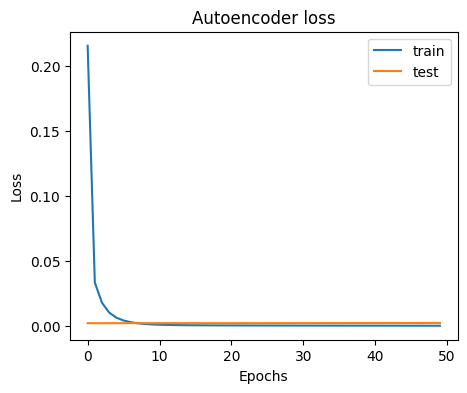

In [29]:
fig, ax = plt.subplots(figsize=(5,4)) 
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.title('Autoencoder loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('Autoencoderloss.png')
     

4/4 [==============================] - 0s 2ms/step


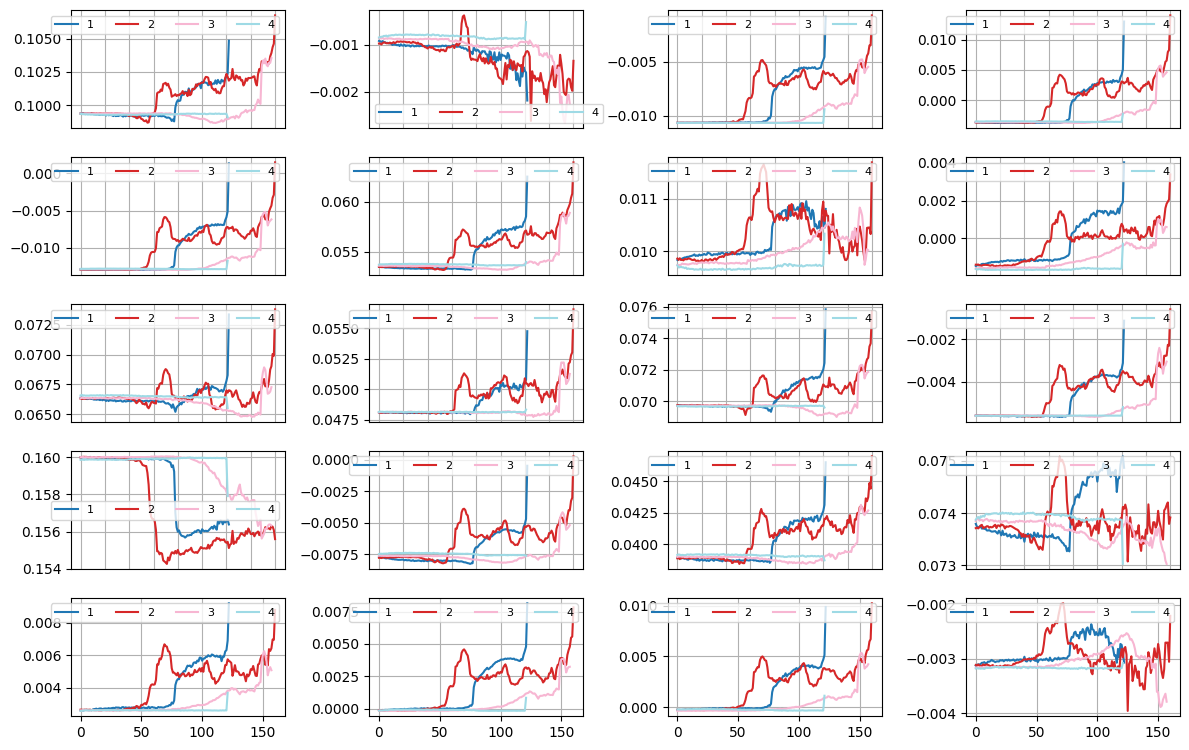

In [33]:
path = r'Dataset\XJTU\STFT\B2_2'
path = r'Dataset\XJTU\STFT\B1_1_env'
frames = []
folder = r'Dataset/XJTU\STFT/'
brngs = ['B1_1_env','B1_2_env','B1_3_env','B1_4_env']

for brng in brngs:
    path = os.path.join(folder, brng)
    data = load_bearing_data(path) # Ex: (123, 257, 129, 1)

    # 3. Junta os dois conjuntos no eixo 0 (amostras)
    X_val = np.concatenate([data], axis=0)
    X_val = (X_val - min_val) / (max_val - min_val)

    Z = encoder.predict(X_val)
    c1,c2,c3 = Z.shape
    Z = np.reshape(Z, (c2, c1, c3))
    #Z = np.reshape(Z, (1, 123, 32))

    df3 = pd.DataFrame(Z[0])
    frames.append(df3)
PlotDataframes(frames)

